# EXIOBASE 3 + pymrio: Sweden GHG hotspots (light / fast version)

This is a **lighter / faster** version of the Sweden notebook.

## What makes it lighter

- It runs **GHG only** (no materials, no factor inputs).
- It computes the footprint using **only the selected GHG air-stressor rows**, not the full air-emissions extension.
- It computes **`S = F / x` manually** for the selected rows only, which avoids the `extension.S` issue seen in the Stockholm prototype.

## Outputs

For **whole Sweden (`SE`)**, the notebook gives:
- GHG **PBA** totals
- GHG **CBA** totals
- top Swedish **PBA sectors**
- top **source countries** in Sweden's GHG footprint
- top **source sectors** in Sweden's GHG footprint
- top **country-sector pairs** in Sweden's GHG footprint
- CSV exports and a couple of quick charts

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymrio
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)

In [2]:
# =========================
# Configuration
# =========================

EXIOBASE_PATH = Path(r"C:/EXIOBASE3/IOT_2024_pxp.zip")
OUTPUT_DIR = Path("./results_sweden_ghg_hotspots_light")
OUTPUT_DIR.mkdir(exist_ok=True)

SWEDEN_CODE = "SE"
TOP_N = 15
TOP_PAIR_N = 25

if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f"EXIOBASE file not found: {EXIOBASE_PATH}")

print(f"EXIOBASE path: {EXIOBASE_PATH}")
print(f"Output dir   : {OUTPUT_DIR.resolve()}")

EXIOBASE path: C:\EXIOBASE3\IOT_2024_pxp.zip
Output dir   : C:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\results_sweden_ghg_hotspots_light


## Exact GHG rows and units

These rows follow the **database stressor list** and use the exact names from your `unit.txt` file.

In [3]:
# =========================
# Exact GHG row list from the database stressor list
# =========================

# Fossil / non-biogenic rows to include
GHG_FOSSIL_ROWS = {
    'CO2': [
        'CO2 - combustion - air',
        'CO2 - non combustion - Cement production - air',
        'CO2 - non combustion - Lime production - air',
        'CO2 - waste - fossil - air',
    ],
    'CH4': [
        'CH4 - combustion - air',
        'CH4 - non combustion - Extraction/production of (natural) gas - air',
        'CH4 - non combustion - Extraction/production of crude oil - air',
        'CH4 - non combustion - Mining of antracite - air',
        'CH4 - non combustion - Mining of bituminous coal - air',
        'CH4 - non combustion - Mining of coking coal - air',
        'CH4 - non combustion - Mining of lignite (brown coal) - air',
        'CH4 - non combustion - Mining of sub-bituminous coal - air',
        'CH4 - non combustion - Oil refinery - air',
        'CH4 - agriculture - air',
        'CH4 - waste - air',
    ],
    'N2O': [
        'N2O - combustion - air',
        'N2O - agriculture - air',
    ],
    'SF6': ['SF6 - air'],
    'HFC': ['HFC - air'],
    'PFC': ['PFC - air'],
}

# Biogenic rows to track separately
GHG_BIOGENIC_ROWS = {
    'CO2': [
        'CO2_bio - combustion - air',
        'CO2 - agriculture - peat decay - air',
        'CO2 - waste - biogenic - air',
    ],
    'CH4': ['CH4_bio - combustion - air'],
    'N2O': ['N2O_bio - combustion - air'],
}

# Exact units from the attached stressor list
GHG_UNITS = {
    'CO2 - combustion - air': 'kg',
    'CO2 - non combustion - Cement production - air': 'kg',
    'CO2 - non combustion - Lime production - air': 'kg',
    'CO2 - waste - fossil - air': 'kg',
    'CH4 - combustion - air': 'kg',
    'CH4 - non combustion - Extraction/production of (natural) gas - air': 'kg',
    'CH4 - non combustion - Extraction/production of crude oil - air': 'kg',
    'CH4 - non combustion - Mining of antracite - air': 'kg',
    'CH4 - non combustion - Mining of bituminous coal - air': 'kg',
    'CH4 - non combustion - Mining of coking coal - air': 'kg',
    'CH4 - non combustion - Mining of lignite (brown coal) - air': 'kg',
    'CH4 - non combustion - Mining of sub-bituminous coal - air': 'kg',
    'CH4 - non combustion - Oil refinery - air': 'kg',
    'CH4 - agriculture - air': 'kg',
    'CH4 - waste - air': 'kg',
    'N2O - combustion - air': 'kg',
    'N2O - agriculture - air': 'kg',
    'SF6 - air': 'kg',
    'HFC - air': 'kg CO2-eq',
    'PFC - air': 'kg CO2-eq',
    'CO2_bio - combustion - air': 'kg',
    'CO2 - agriculture - peat decay - air': 'kg',
    'CO2 - waste - biogenic - air': 'kg',
    'CH4_bio - combustion - air': 'kg',
    'N2O_bio - combustion - air': 'kg',
}

GWP = {
    'CO2': 1,
    'CH4': 28,
    'N2O': 265,
    'SF6': 23500,
    'HFC': 1,  # already CO2-eq
    'PFC': 1,  # already CO2-eq
}

ALL_GHG_ROWS = []
for d in [GHG_FOSSIL_ROWS, GHG_BIOGENIC_ROWS]:
    for gas, rows in d.items():
        ALL_GHG_ROWS.extend(rows)

print(f"Selected GHG rows: {len(ALL_GHG_ROWS)}")

Selected GHG rows: 25


In [4]:
# =========================
# Load EXIOBASE and compute only the system pieces we need
# =========================

exio = pymrio.parse_exiobase3(path=str(EXIOBASE_PATH))

# Prefer a lighter system calculation if available; otherwise fall back to calc_all().
if hasattr(exio, 'calc_system'):
    exio.calc_system()
else:
    exio.calc_all()

print(exio.meta)
print()
print(f"Regions : {len(exio.get_regions())}")
print(f"Sectors : {len(exio.get_sectors())}")

Description: EXIOBASE version 3.10.1 - pxp for 2024
MRIO Name: EXIO_IOT_2024_pxp
System: pxp
Version: 3.10.1
File: None
History:
20260415 18:13:08 - MODIFICATION -  Leontief matrix L calculated
20260415 18:12:54 - MODIFICATION -  Coefficient matrix A calculated
20260415 18:12:54 - MODIFICATION -  Changed country names
20260415 18:12:54 - FILEIO -  Added satellite account from material
20260415 18:12:53 - FILEIO -  Added satellite account from land
20260415 18:12:53 - FILEIO -  Added satellite account from factor_inputs
20260415 18:12:53 - FILEIO -  Added satellite account from water
20260415 18:12:53 - FILEIO -  Added satellite account from nutrients
20260415 18:12:53 - FILEIO -  Added satellite account from air_emissions
20260415 18:12:33 - FILEIO -  Loaded IO system from C:\EXIOBASE3\IOT_2024_pxp.zip - 

Regions : 49
Sectors : 200


In [5]:
# =========================
# Readable region labels
# =========================

REGION_NAME_MAP = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CY': 'Cyprus', 'CZ': 'Czechia',
    'DE': 'Germany', 'DK': 'Denmark', 'EE': 'Estonia', 'ES': 'Spain', 'FI': 'Finland',
    'FR': 'France', 'GR': 'Greece', 'HU': 'Hungary', 'IE': 'Ireland', 'IT': 'Italy',
    'LT': 'Lithuania', 'LU': 'Luxembourg', 'LV': 'Latvia', 'MT': 'Malta', 'NL': 'Netherlands',
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SE': 'Sweden', 'SI': 'Slovenia',
    'SK': 'Slovakia', 'GB': 'United Kingdom', 'US': 'United States', 'JP': 'Japan',
    'CN': 'China', 'CA': 'Canada', 'KR': 'South Korea', 'BR': 'Brazil', 'IN': 'India',
    'MX': 'Mexico', 'RU': 'Russia', 'AU': 'Australia', 'CH': 'Switzerland', 'TR': 'Türkiye',
    'TW': 'Taiwan', 'NO': 'Norway', 'ID': 'Indonesia', 'ZA': 'South Africa',
    'WA': 'Rest of Asia', 'WL': 'Rest of Latin America', 'WE': 'Rest of Europe',
    'WF': 'Rest of Africa', 'WM': 'Rest of Middle East'
}

def region_name(code):
    return REGION_NAME_MAP.get(code, code)

def pretty_pair(idx):
    region, sector = idx
    return f"{region_name(region)} — {sector}"

In [6]:
# =========================
# Helper functions
# =========================

def select_region_columns(df: pd.DataFrame, region_code: str) -> pd.DataFrame:
    mask = df.columns.get_level_values(0) == region_code
    return df.loc[:, mask]


def final_demand_vector(Y: pd.DataFrame, region_code: str) -> pd.Series:
    y = Y.xs(region_code, axis=1, level=0).sum(axis=1)
    y.name = region_code
    return y


def unit_to_kt_factor(unit_value: str) -> float:
    u = str(unit_value).lower()
    if 'kg co2-eq' in u:
        return 1 / 1e6
    if 'kg' in u:
        return 1 / 1e6
    if 'kt' in u:
        return 1.0
    if 't' in u or 'ton' in u:
        return 1 / 1e3
    raise ValueError(f"Unknown unit: {unit_value}")


def make_ghg_metadata() -> pd.DataFrame:
    rows = []
    for gas, lst in GHG_FOSSIL_ROWS.items():
        for r in lst:
            rows.append({
                'category': 'fossil_ghg', 'gas': gas, 'row': r,
                'unit': GHG_UNITS[r], 'gwp': GWP[gas], 'to_kt_factor': unit_to_kt_factor(GHG_UNITS[r])
            })
    for gas, lst in GHG_BIOGENIC_ROWS.items():
        for r in lst:
            rows.append({
                'category': 'biogenic_ghg', 'gas': gas, 'row': r,
                'unit': GHG_UNITS[r], 'gwp': GWP[gas], 'to_kt_factor': unit_to_kt_factor(GHG_UNITS[r])
            })
    return pd.DataFrame(rows)


def aggregate_ghg_exact(F_selected: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    out = {}
    for category in ['fossil_ghg', 'biogenic_ghg']:
        total = 0
        sub = meta.loc[meta['category'] == category]
        for _, row in sub.iterrows():
            total = total + F_selected.loc[row['row']] * float(row['gwp']) * float(row['to_kt_factor'])
        out[category] = total
    return pd.DataFrame(out).T

In [7]:
# =========================
# Sanity check against database row names
# =========================

available_rows = set(exio.air_emissions.F.index.tolist())
missing = [r for r in ALL_GHG_ROWS if r not in available_rows]

if missing:
    print('Missing GHG rows:')
    for r in missing:
        print(' -', r)
    raise ValueError('Some required GHG rows are missing from exio.air_emissions.F.index')
else:
    print('All selected GHG rows found in exio.air_emissions.F.index')

meta_ghg = make_ghg_metadata()
display(meta_ghg)

All selected GHG rows found in exio.air_emissions.F.index


,category,gas,row,unit,gwp,to_kt_factor
0,fossil_ghg,CO2,CO2 - combustion - air,kg,1,0.000001
1,fossil_ghg,CO2,CO2 - non combustion - Cement production - air,kg,1,0.000001
2,fossil_ghg,CO2,CO2 - non combustion - Lime production - air,kg,1,0.000001
3,fossil_ghg,CO2,CO2 - waste - fossil - air,kg,1,0.000001
4,fossil_ghg,CH4,CH4 - combustion - air,kg,28,0.000001
5,fossil_ghg,CH4,CH4 - non combustion - Extraction/production o...,kg,28,0.000001
6,fossil_ghg,CH4,CH4 - non combustion - Extraction/production o...,kg,28,0.000001
7,fossil_ghg,CH4,CH4 - non combustion - Mining of antracite - air,kg,28,0.000001
8,fossil_ghg,CH4,CH4 - non combustion - Mining of bituminous co...,kg,28,0.000001
9,fossil_ghg,CH4,CH4 - non combustion - Mining of coking coal -...,kg,28,0.000001


In [8]:
# =========================
# Sweden vectors and selected GHG data
# =========================

y_se = final_demand_vector(exio.Y, SWEDEN_CODE)
x_series = exio.x.squeeze()

F_ghg = exio.air_emissions.F.loc[ALL_GHG_ROWS].copy()

print(f"Selected F_ghg shape: {F_ghg.shape}")
print(f"Total Swedish final demand sum: {y_se.sum():,.3f}")

Selected F_ghg shape: (25, 9800)
Total Swedish final demand sum: 537,934.439


In [10]:
# =========================
# Production-based account (PBA) for Sweden
# =========================

F_ghg_se = select_region_columns(F_ghg, SWEDEN_CODE)
ghg_pba_df = aggregate_ghg_exact(F_ghg_se, meta_ghg)
ghg_pba_totals = ghg_pba_df.sum(axis=1).rename('PBA_Sweden_ktCO2e')

ghg_pba_sector = ghg_pba_df.sum(axis=0)
ghg_pba_sector = ghg_pba_sector.groupby(level=1).sum().sort_values(ascending=False)

print('GHG PBA totals for Sweden:')
display(ghg_pba_totals.to_frame())
print('Top Swedish GHG PBA sectors:')
display(ghg_pba_sector.head(TOP_N).to_frame('kt CO2e'))

GHG PBA totals for Sweden:


,PBA_Sweden_ktCO2e
fossil_ghg,24993.343948
biogenic_ghg,427.943564


Top Swedish GHG PBA sectors:


,kt CO2e
sector,
Paper for treatment: landfill,6245.776484
Food waste for treatment: landfill,5955.943086
Raw milk,3909.978020
Cattle,2389.110581
"Cement, lime and plaster",1255.392227
Cereal grains nec,1064.717068
Wheat,581.684123
Plastic waste for treatment: landfill,478.944249
Oil seeds,261.562604


In [11]:
# =========================
# Consumption-based account (CBA) for Sweden
# Fast version: use only selected GHG rows
# =========================

x_safe = x_series.replace(0, np.nan)
S_ghg = F_ghg.div(x_safe, axis=1).fillna(0)
M_ghg = S_ghg @ exio.L
footprint_ghg = M_ghg.multiply(y_se, axis=1)

ghg_cba_df = aggregate_ghg_exact(footprint_ghg, meta_ghg)
ghg_cba_totals = ghg_cba_df.sum(axis=1).rename('CBA_Sweden_ktCO2e')

print('GHG CBA totals for Sweden:')
display(ghg_cba_totals.to_frame())

GHG CBA totals for Sweden:


,CBA_Sweden_ktCO2e
fossil_ghg,783346.154983
biogenic_ghg,8068.335202


In [13]:
# =========================
# Hotspots: source countries, sectors, country-sector pairs
# =========================

source_pairs = ghg_cba_df.sum(axis=0).sort_values(ascending=False)
source_countries = source_pairs.groupby(level=0).sum().sort_values(ascending=False)
source_sectors = source_pairs.groupby(level=1).sum().sort_values(ascending=False)

pairs_pretty = source_pairs.head(TOP_PAIR_N).to_frame('kt CO2e')
pairs_pretty['source'] = [pretty_pair(idx) for idx in pairs_pretty.index]
pairs_pretty = pairs_pretty[['source', 'kt CO2e']]

print('Top source countries in Sweden GHG footprint:')
display(source_countries.head(TOP_N).rename(index=region_name).to_frame('kt CO2e'))
print('Top source sectors in Sweden GHG footprint:')
display(source_sectors.head(TOP_N).to_frame('kt CO2e'))
print('Top country-sector pairs in Sweden GHG footprint:')
display(pairs_pretty)

Top source countries in Sweden GHG footprint:


,kt CO2e
region,
Sweden,317203.514739
Switzerland,287147.143125
Germany,46289.899056
Italy,15019.993483
Netherlands,14629.053833
Denmark,12328.866133
France,12070.798818
Ireland,9113.286480
Rest of Asia,7531.187331


Top source sectors in Sweden GHG footprint:


,kt CO2e
sector,
Hotel and restaurant services (55),117781.794939
Dairy products,109780.413471
"Retail trade services, except of motor vehicles and motorcycles; repair services of personal and household goods (52)",57846.034132
Food products nec,55492.536936
Public administration and defence services; compulsory social security services (75),47172.944267
Construction work (45),44312.004424
Computer and related services (72),32152.199860
Education services (80),30993.313096
Health and social work services (85),27101.433894


Top country-sector pairs in Sweden GHG footprint:


source       kt CO2e
region sector                                                                                                             
CH     Hotel and restaurant services (55)                   Switzerland — Hotel and restaurant services (55)  85056.296115
       Dairy products                                                           Switzerland — Dairy products  54878.450199
SE     Retail  trade services, except of motor vehicle...  Sweden — Retail  trade services, except of mot...  45107.698609
       Construction work (45)                                                Sweden — Construction work (45)  40231.647550
       Education services (80)                                              Sweden — Education services (80)  28963.185270
CH     Public administration and defence services; com...  Switzerland — Public administration and defenc...  28713.638476
SE     Dairy products                                                                Sweden — Dairy products  25410.117480
CH     Food products nec                                                     Switzerland — Food products nec  25264.513991
SE     Health and social work services (85)                    Sweden — Health and social work services (85)  23858.583809
       Computer and related services (72)                        Sweden — Computer and related services (72)  21555.339553
       Wholesale trade and commission trade services, ...  Sweden — Wholesale trade and commission trade ...  19300.558974
       Public administration and defence services; com...  Sweden — Public administration and defence ser...  17748.877237
CH     Wearing apparel; furs (18)                                   Switzerland — Wearing apparel; furs (18)  12397.167683
       Retail  trade services, except of motor vehicle...  Switzerland — Retail  trade services, except o...  12194.509268
DE     Dairy products                                                               Germany — Dairy products  11578.187124
CH     Textiles (17)                                                             Switzerland — Textiles (17)   9064.988740
       Post and telecommunication services (64)            Switzerland — Post and telecommunication servi...   9059.880431
SE     Food products nec                                                          Sweden — Food products nec   8829.891212
DE     Hotel and restaurant services (55)                       Germany — Hotel and restaurant services (55)   8667.303178
SE     Renting services of machinery and equipment wit...  Sweden — Renting services of machinery and equ...   8510.418121
CH     Research and development services (73)              Switzerland — Research and development service...   7611.341272
IT     Dairy products                                                                 Italy — Dairy products   7444.752893
IE     Computer and related services (72)                       Ireland — Computer and related services (72)   6997.794111
SE     Financial intermediation services, except insur...  Sweden — Financial intermediation services, ex...   6800.494362
       Sea and coastal water transportation services       Sweden — Sea and coastal water transportation ...   6404.870638

In [14]:
# =========================
# Combined summary
# =========================

summary = pd.concat([ghg_pba_totals, ghg_cba_totals], axis=1)
summary['Net_PBA_minus_CBA'] = summary.iloc[:, 0] - summary.iloc[:, 1]
summary.loc['total_ghg'] = summary.sum(axis=0)

print('Combined Sweden GHG summary:')
display(summary)

Combined Sweden GHG summary:


,PBA_Sweden_ktCO2e,CBA_Sweden_ktCO2e,Net_PBA_minus_CBA
fossil_ghg,24993.343948,783346.154983,-758352.811035
biogenic_ghg,427.943564,8068.335202,-7640.391638
total_ghg,25421.287512,791414.490185,-765993.202672


In [15]:
# =========================
# Save CSV outputs
# =========================

summary.to_csv(OUTPUT_DIR / 'sweden_ghg_summary_light.csv')
ghg_pba_sector.head(TOP_N).to_frame('kt CO2e').to_csv(OUTPUT_DIR / 'sweden_ghg_top_pba_sectors_light.csv')
source_countries.head(TOP_N).rename(index=region_name).to_frame('kt CO2e').to_csv(OUTPUT_DIR / 'sweden_ghg_top_source_countries_light.csv')
source_sectors.head(TOP_N).to_frame('kt CO2e').to_csv(OUTPUT_DIR / 'sweden_ghg_top_source_sectors_light.csv')
pairs_pretty.to_csv(OUTPUT_DIR / 'sweden_ghg_top_country_sector_pairs_light.csv', index=False)

print(f"CSV files written to: {OUTPUT_DIR.resolve()}")

CSV files written to: C:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\results_sweden_ghg_hotspots_light


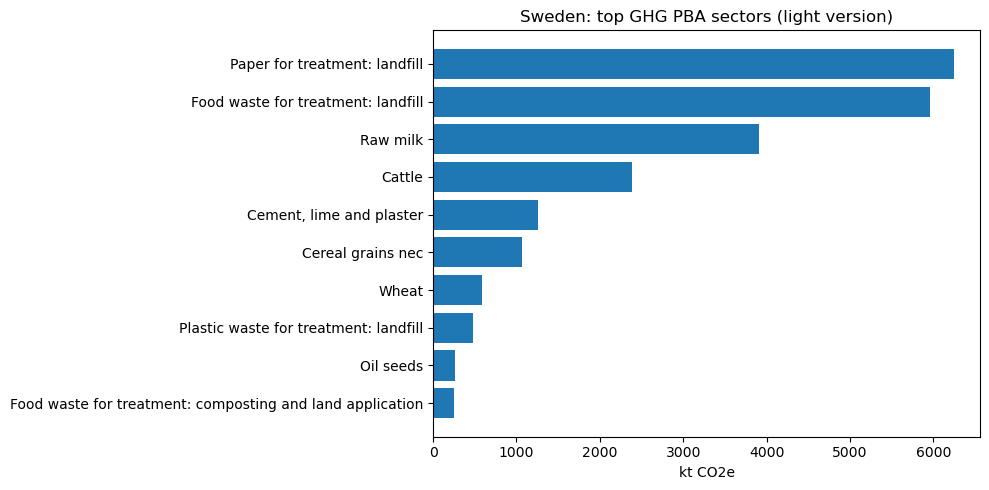

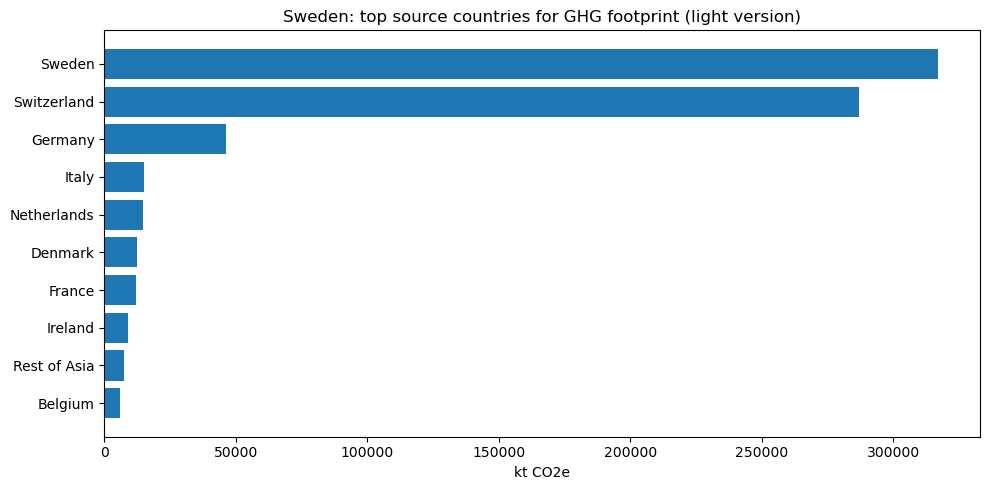

In [16]:
# =========================
# Quick charts
# =========================

def barh_plot(series, title, xlabel, filename, top_n=10):
    s = series.head(top_n).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(s.index.astype(str), s.values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

barh_plot(ghg_pba_sector, 'Sweden: top GHG PBA sectors (light version)', 'kt CO2e', 'chart_ghg_pba_sectors_light.png')
barh_plot(source_countries.rename(index=region_name), 'Sweden: top source countries for GHG footprint (light version)', 'kt CO2e', 'chart_ghg_source_countries_light.png')

## Notes

- This notebook is intentionally narrow: **GHG hotspots only**.
- It uses the **exact stressor names and units** from the attached `unit.txt` list, which is both faster and more robust than fuzzy row matching.
- Since `HFC - air` and `PFC - air` are already in **kg CO2-eq**, their GWP factor is set to **1**.
- `SF6 - air` is in **kg** and therefore gets a GWP conversion before aggregation.